# Lab Assignment 3 




In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)


### A.1 Data Acquisition



In [3]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
             "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df_tab = pd.read_csv(pima_url, names=pima_cols)
print(df_tab.shape)
df_tab.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### A.2 Inspection


In [4]:
df_tab.info()
df_tab.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### A.3 Cleaning — Why healthcare data needs extra care




In [5]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Zero-value counts before cleaning:")
print((df_tab[zero_as_missing_cols] == 0).sum())

df_clean = df_tab.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

print("\nMissing values after marking implausible zeros as NaN:")
print(df_clean.isnull().sum())


Zero-value counts before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after marking implausible zeros as NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [6]:
for col in zero_as_missing_cols:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda s: s.fillna(s.median()))

print("Missing values after imputation:", df_clean.isnull().sum().sum())
df_clean.head()


Missing values after imputation: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


### A.4 Exploratory Data Analysis


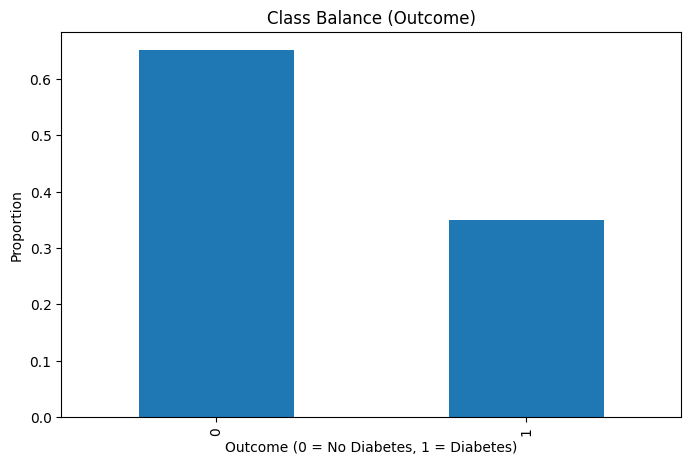

In [7]:
df_clean["Outcome"].value_counts(normalize=True).plot(kind="bar", title="Class Balance (Outcome)")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Proportion")
plt.show()


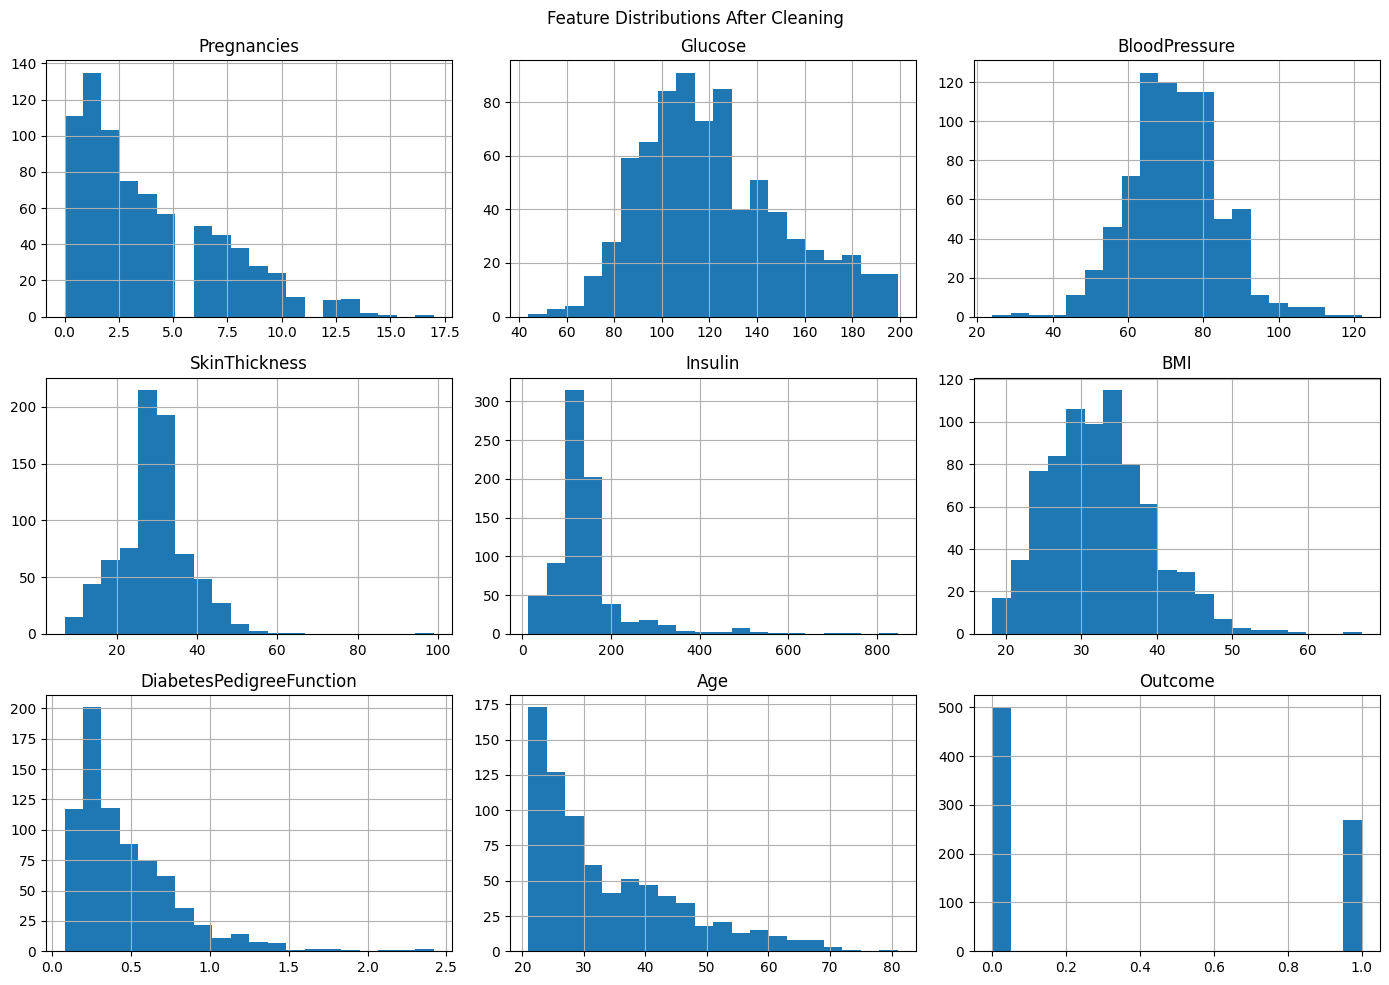

In [8]:
df_clean.hist(bins=20, figsize=(14, 10))
plt.suptitle("Feature Distributions After Cleaning")
plt.tight_layout()
plt.show()


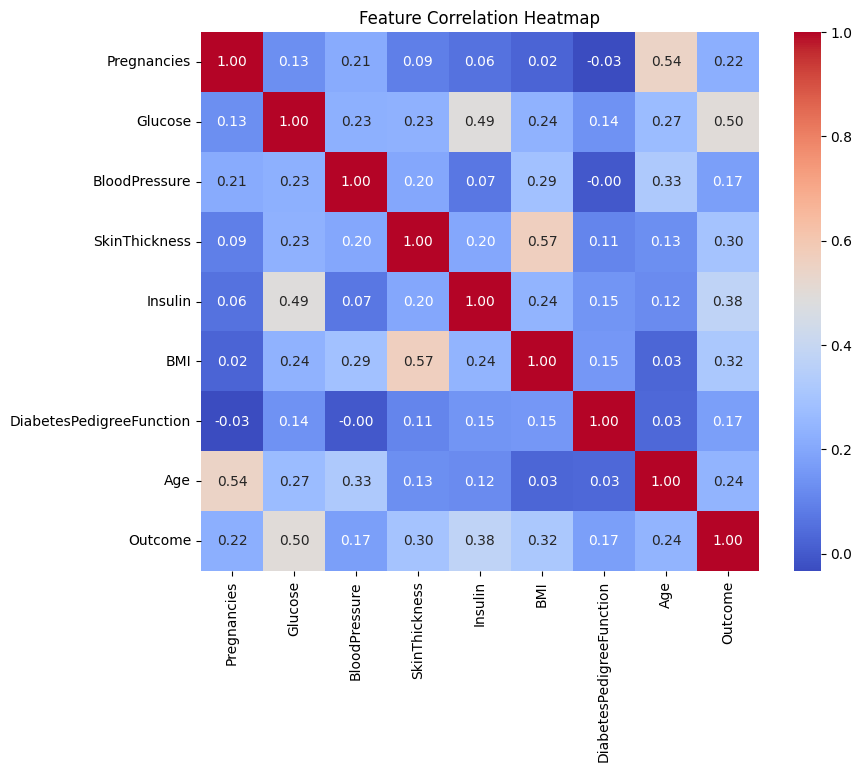

In [9]:
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


### A.5 Hypothesis Testing (t-test)



In [10]:
from scipy import stats

group0 = df_clean.loc[df_clean.Outcome == 0, "Glucose"]
group1 = df_clean.loc[df_clean.Outcome == 1, "Glucose"]

t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.6f}")

alpha = 0.05
if p_val < alpha:
    print("Reject H0: Glucose levels differ significantly between the two groups.")
else:
    print("Fail to reject H0: no significant difference detected.")


t-statistic = -14.992, p-value = 0.000000
Reject H0: Glucose levels differ significantly between the two groups.


### A.6 Chi-Square Test



In [11]:
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[20, 30, 40, 50, 60, 100],
    labels=["21-30", "31-40", "41-50", "51-60", "60+"]
)

contingency = pd.crosstab(df_clean["AgeGroup"], df_clean["Outcome"])
print(contingency)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2 = {chi2:.3f}, p-value = {p_val:.6f}, dof = {dof}")

if p_val < alpha:
    print("Reject H0: Age group and diabetes outcome are associated.")
else:
    print("Fail to reject H0: no significant association detected.")


Outcome     0   1
AgeGroup         
21-30     327  90
31-40      81  76
41-50      49  64
51-60      23  31
60+        20   7

chi2 = 81.661, p-value = 0.000000, dof = 4
Reject H0: Age group and diabetes outcome are associated.


### A.7 ANOVA



In [12]:
bmi_groups = [df_clean.loc[df_clean.AgeGroup == g, "BMI"].dropna() for g in df_clean["AgeGroup"].cat.categories]

f_stat, p_val = stats.f_oneway(*bmi_groups)
print(f"F-statistic = {f_stat:.3f}, p-value = {p_val:.6f}")

if p_val < alpha:
    print("Reject H0: mean BMI differs across at least one age group.")
else:
    print("Fail to reject H0: no significant difference in mean BMI across age groups.")


F-statistic = 4.602, p-value = 0.001121
Reject H0: mean BMI differs across at least one age group.


### A.8 Feature Engineering, Selection & Model-Ready Scaling


In [13]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df_clean["BMI_Category"] = df_clean["BMI"].apply(bmi_category)
df_clean[["BMI", "BMI_Category", "AgeGroup"]].head()


,BMI,BMI_Category,AgeGroup
0,33.6,Obese,41-50
1,26.6,Overweight,31-40
2,23.3,Normal,31-40
3,28.1,Overweight,21-30
4,43.1,Obese,31-40


In [14]:
from sklearn.preprocessing import StandardScaler

feature_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

scaler = StandardScaler()
X_tabular = scaler.fit_transform(df_clean[feature_cols])
y_tabular = df_clean["Outcome"].values

print("Model-ready tabular tensor shape:", X_tabular.shape)
X_tabular[:3]


Model-ready tabular tensor shape: (768, 8)


array([[ 0.63994726,  0.86462486, -0.03218035,  0.66518138,  0.31160394,
         0.16948251,  0.46849198,  1.4259954 ],
       [-0.84488505, -1.20472661, -0.52812374, -0.01011181, -0.44084303,
        -0.84854874, -0.36506078, -0.19067191],
       [ 1.23388019,  2.01426457, -0.69343821,  0.32753478,  0.31160394,
        -1.32847775,  0.60439732, -0.10558415]])

### B.1 Data Acquisition



In [15]:
mtsamples_url = "https://raw.githubusercontent.com/aneuraz/mtsamplesFR/master/data/mtsamples.csv"

df_text = pd.read_csv(mtsamples_url)
print(df_text.shape)
df_text.head()


(4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


### B.2 Inspection


In [16]:
df_text.info()
print("\nMissing values:\n", df_text.isnull().sum())
print("\nUnique medical specialties:", df_text['medical_specialty'].nunique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB

Missing values:
 Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Unique medical specialties: 40


### B.3 Cleaning



In [17]:
df_text_clean = df_text.dropna(subset=["transcription"]).copy()

def scrub_phi(text):
    text = re.sub(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', '[DATE]', text)     # dates
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', '[PHONE]', text)         # phone numbers
    text = re.sub(r'\bMR#?\s*\d+\b', '[MRN]', text, flags=re.IGNORECASE)      # medical record numbers
    text = re.sub(r'\bDr\.?\s+[A-Z][a-z]+\b', '[DOCTOR]', text)               # doctor names
    return text

df_text_clean["transcription_scrubbed"] = df_text_clean["transcription"].apply(scrub_phi)
df_text_clean[["transcription", "transcription_scrubbed"]].head(2)


,transcription,transcription_scrubbed
0,"SUBJECTIVE:, This 23-year-old white female pr...","SUBJECTIVE:, This 23-year-old white female pr..."
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","PAST MEDICAL HISTORY:, He has difficulty climb..."


### B.4 Preprocessing → Token Sequences



In [18]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df_text_clean["tokens"] = df_text_clean["transcription_scrubbed"].apply(preprocess_text)
df_text_clean[["transcription_scrubbed", "tokens"]].head(2)


,transcription_scrubbed,tokens
0,"SUBJECTIVE:, This 23-year-old white female pr...","[subjective, year, old, white, female, present..."
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","[past, medical, history, difficulty, climbing,..."


### B.5 Exploratory Data Analysis


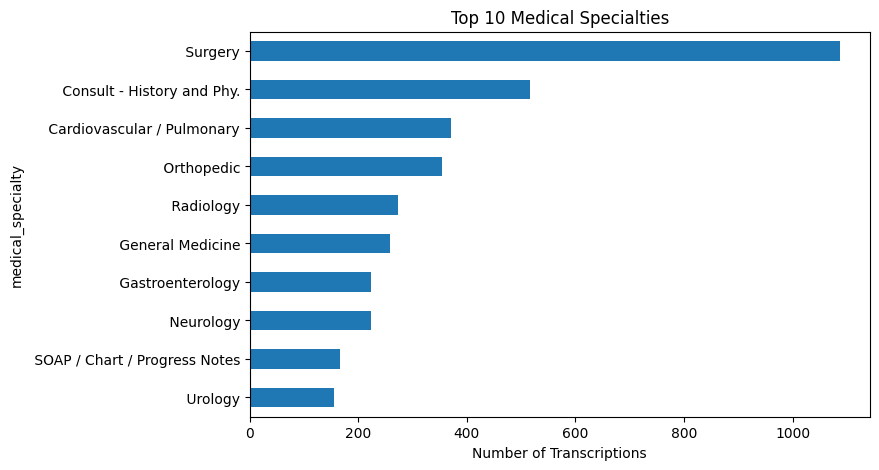

In [19]:
df_text_clean["medical_specialty"].value_counts().head(10).plot(kind="barh", title="Top 10 Medical Specialties")
plt.xlabel("Number of Transcriptions")
plt.gca().invert_yaxis()
plt.show()


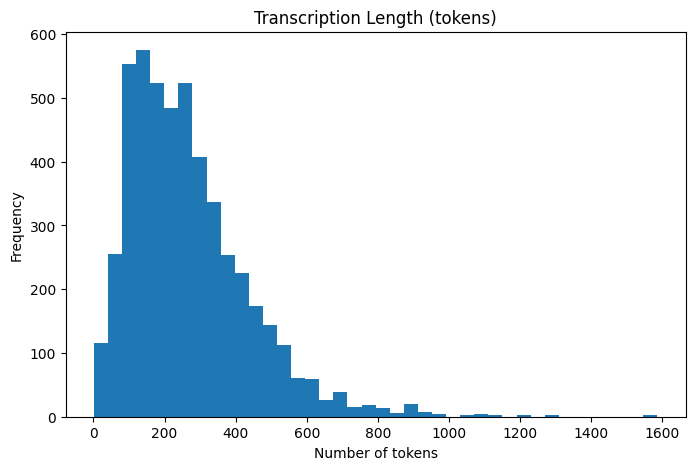

In [20]:
df_text_clean["token_count"] = df_text_clean["tokens"].apply(len)
df_text_clean["token_count"].plot(kind="hist", bins=40, title="Transcription Length (tokens)")
plt.xlabel("Number of tokens")
plt.show()


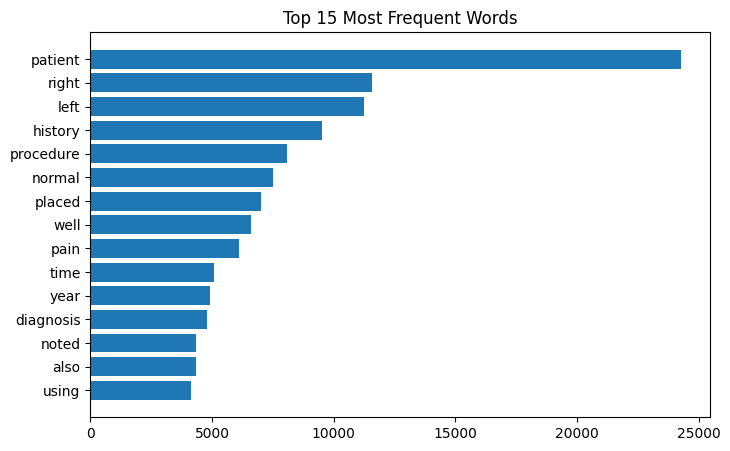

In [21]:
from collections import Counter

all_tokens = [tok for tokens in df_text_clean["tokens"] for tok in tokens]
top_words = Counter(all_tokens).most_common(15)

words, counts = zip(*top_words)
plt.barh(words, counts)
plt.title("Top 15 Most Frequent Words")
plt.gca().invert_yaxis()
plt.show()


### B.6 Feature Extraction — TF-IDF


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

df_text_clean["clean_text"] = df_text_clean["tokens"].apply(lambda toks: " ".join(toks))

tfidf = TfidfVectorizer(max_features=500)
X_text = tfidf.fit_transform(df_text_clean["clean_text"])

print("Model-ready text tensor shape:", X_text.shape)


Model-ready text tensor shape: (4966, 500)


### C.1 Data Acquisition



In [23]:
!pip install -q datasets

from datasets import load_dataset

chest_xray_ds = load_dataset("mmenendezg/raw_pneumonia_x_ray")
print(chest_xray_ds)


README.md:   0%|          | 0.00/674 [00:00<?, ?B/s]

data/train-00000-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  458MB            

data/train-00000-of-00007.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  373MB            

data/train-00001-of-00007.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  111MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5232 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/624 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5232
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})


### C.2 Inspection


In [24]:
for split in chest_xray_ds:
    labels = chest_xray_ds[split]["label"]
    print(f"{split}: NORMAL={labels.count(0)}, PNEUMONIA={labels.count(1)}")


train: NORMAL=1349, PNEUMONIA=3883
test: NORMAL=234, PNEUMONIA=390


### C.3 Cleaning



In [26]:
def load_clean_image(pil_img, size=(150, 150)):
    """Take a PIL image, strip metadata by re-encoding as grayscale, resize, return array."""
    try:
        img = pil_img.convert("L")
        img = img.resize(size)
        return np.array(img)
    except Exception:
        return None

sample = chest_xray_ds["train"].select(range(50))
bad = sum(1 for ex in sample if load_clean_image(ex["image"]) is None)
print(f"Corrupt/unreadable images in sample: {bad}/{len(sample)}")


Corrupt/unreadable images in sample: 0/50


### C.4 Preprocessing → Model-Ready Tensors



In [27]:
def build_image_tensor(dataset_split, label_value, limit=150, size=(150, 150)):
    idxs = [i for i, lbl in enumerate(dataset_split["label"]) if lbl == label_value][:limit]
    images = []
    for i in idxs:
        arr = load_clean_image(dataset_split[i]["image"], size)
        if arr is not None:
            images.append(arr / 255.0)
    return images

normal_imgs = build_image_tensor(chest_xray_ds["train"], label_value=0)
pneu_imgs = build_image_tensor(chest_xray_ds["train"], label_value=1)

X_image = np.array(normal_imgs + pneu_imgs)
y_image = np.array([0] * len(normal_imgs) + [1] * len(pneu_imgs))

print("Model-ready image tensor shape:", X_image.shape)


Model-ready image tensor shape: (300, 150, 150)


### C.5 Exploratory Data Analysis


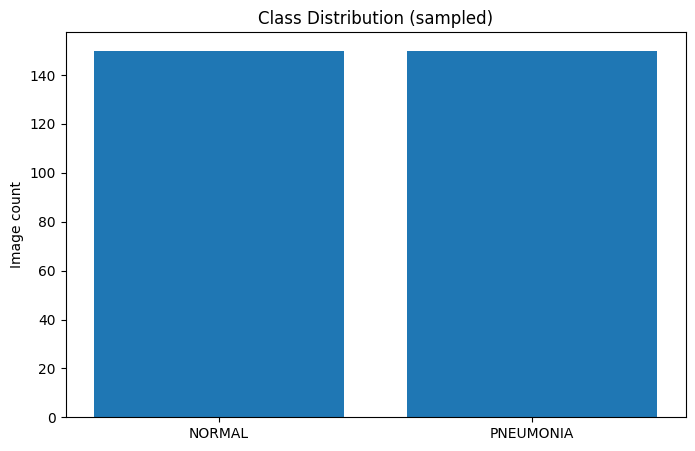

In [28]:
plt.bar(["NORMAL", "PNEUMONIA"], [len(normal_imgs), len(pneu_imgs)])
plt.title("Class Distribution (sampled)")
plt.ylabel("Image count")
plt.show()


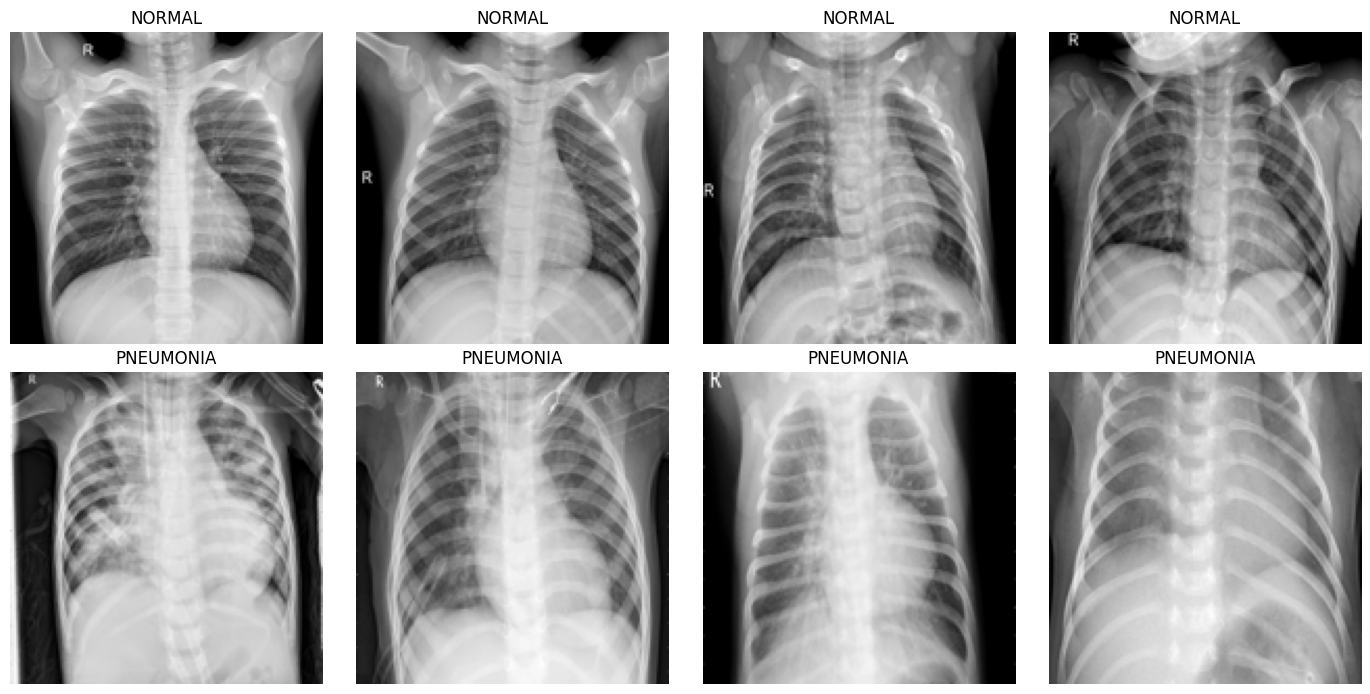

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(normal_imgs[i], cmap="gray")
    axes[0, i].set_title("NORMAL")
    axes[0, i].axis("off")
    axes[1, i].imshow(pneu_imgs[i], cmap="gray")
    axes[1, i].set_title("PNEUMONIA")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


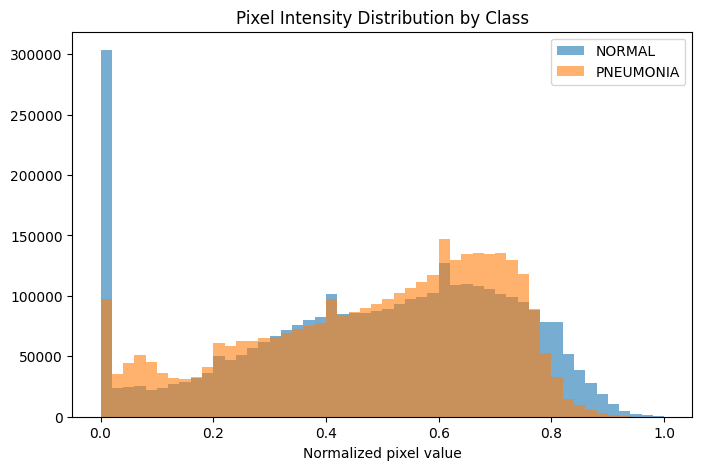

In [30]:
plt.hist(X_image[y_image == 0].ravel(), bins=50, alpha=0.6, label="NORMAL")
plt.hist(X_image[y_image == 1].ravel(), bins=50, alpha=0.6, label="PNEUMONIA")
plt.title("Pixel Intensity Distribution by Class")
plt.xlabel("Normalized pixel value")
plt.legend()
plt.show()


### C.6 Augmentation



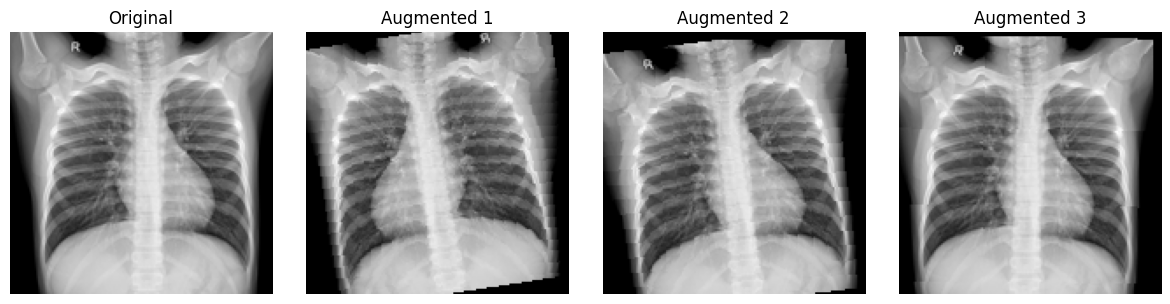

In [31]:
from torchvision import transforms
from PIL import Image as PILImage

augment = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(0, translate=(0.05, 0.05)),
])

sample_img = PILImage.fromarray((normal_imgs[0] * 255).astype(np.uint8))

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    aug_img = augment(sample_img) if i > 0 else sample_img
    ax.imshow(aug_img, cmap="gray")
    ax.set_title("Original" if i == 0 else f"Augmented {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()


### D.1 Data Acquisition



In [32]:
import wfdb

record_name = "100"
wfdb.dl_database('mitdb', dl_dir='mitdb', records=[record_name])

record = wfdb.rdrecord(f'mitdb/{record_name}')
annotation = wfdb.rdann(f'mitdb/{record_name}', 'atr')

print("Signal shape:", record.p_signal.shape)
print("Sampling rate:", record.fs, "Hz")
print("Lead names:", record.sig_name)


Generating record list for: 100
Generating list of all files for: 100
Created local base download directory: mitdb
Finished downloading files
Signal shape: (650000, 2)
Sampling rate: 360 Hz
Lead names: ['MLII', 'V5']


### D.2 Inspection


In [33]:
ecg_signal = record.p_signal[:, 0]
print("Total samples:", len(ecg_signal))
print("Duration (s):", len(ecg_signal) / record.fs)
print("Number of annotated beats:", len(annotation.sample))
print("Unique beat annotation symbols:", set(annotation.symbol))


Total samples: 650000
Duration (s): 1805.5555555555557
Number of annotated beats: 2274
Unique beat annotation symbols: {'+', 'N', 'A', 'V'}


### D.3 Cleaning — Noise Removal



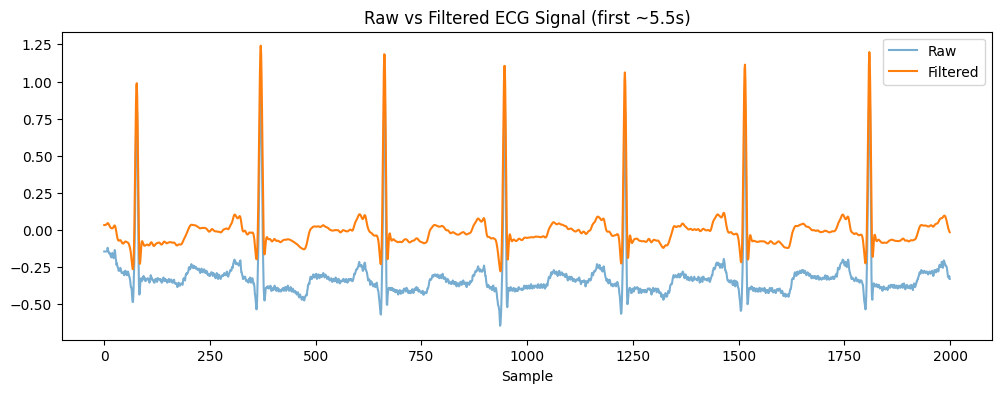

In [34]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, fs, low=0.5, high=40, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, signal)

ecg_filtered = bandpass_filter(ecg_signal, record.fs)

plt.figure(figsize=(12, 4))
window = slice(0, 2000)
plt.plot(ecg_signal[window], alpha=0.6, label="Raw")
plt.plot(ecg_filtered[window], label="Filtered")
plt.title("Raw vs Filtered ECG Signal (first ~5.5s)")
plt.xlabel("Sample")
plt.legend()
plt.show()


### D.4 Preprocessing — Signal Windowing



In [35]:
def segment_beats(signal, r_peaks, fs, window_sec=0.6):
    half_win = int((window_sec / 2) * fs)
    beats = []
    for peak in r_peaks:
        start, end = peak - half_win, peak + half_win
        if start >= 0 and end < len(signal):
            beats.append(signal[start:end])
    return np.array(beats)

beat_windows = segment_beats(ecg_filtered, annotation.sample, record.fs)
print("Model-ready signal tensor shape (beats x samples):", beat_windows.shape)


Model-ready signal tensor shape (beats x samples): (2271, 216)


### D.5 Exploratory Data Analysis


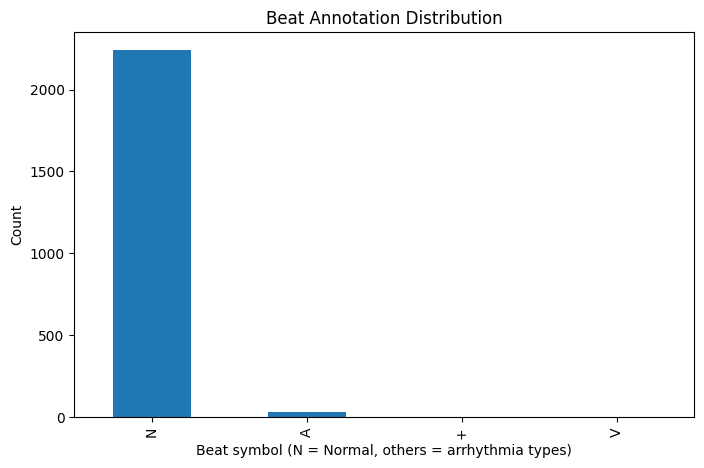

In [36]:
beat_counts = pd.Series(annotation.symbol).value_counts()
beat_counts.plot(kind="bar", title="Beat Annotation Distribution")
plt.xlabel("Beat symbol (N = Normal, others = arrhythmia types)")
plt.ylabel("Count")
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.plot(beat_windows[i])
    ax.set_title(f"Beat {i} (symbol: {annotation.symbol[i]})")
plt.tight_layout()
plt.show()


### D.6 Feature Extraction — RR Intervals & Heart Rate Variability



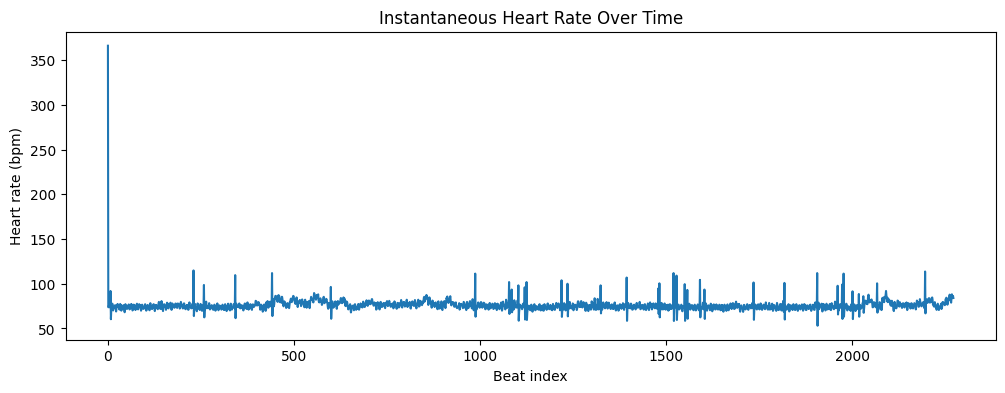

Mean RR interval: 0.794s
HRV (std of RR intervals): 0.0506s


In [37]:
rr_intervals = np.diff(annotation.sample) / record.fs
heart_rate = 60 / rr_intervals

plt.figure(figsize=(12, 4))
plt.plot(heart_rate)
plt.title("Instantaneous Heart Rate Over Time")
plt.xlabel("Beat index")
plt.ylabel("Heart rate (bpm)")
plt.show()

print(f"Mean RR interval: {rr_intervals.mean():.3f}s")
print(f"HRV (std of RR intervals): {rr_intervals.std():.4f}s")
